<a href="https://colab.research.google.com/github/ritam-sarkar/ml-practice/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
df = pd.read_csv('Titanic-Dataset.csv')
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
214,215,0,3,"Kiernan, Mr. Philip",male,NaN,1,0,367229,7.75,NaN,Q
441,442,0,3,"Hampe, Mr. Leon",male,20.0,0,0,345769,9.50,NaN,S
740,741,1,1,"Hawksford, Mr. Walter James",male,NaN,0,0,16988,30.00,D45,S
225,226,0,3,"Berglund, Mr. Karl Ivar Sven",male,22.0,0,0,PP 4348,9.35,NaN,S
141,142,1,3,"Nysten, Miss. Anna Sofia",female,22.0,0,0,347081,7.75,NaN,S


### Describe the data

In [3]:
print(df.shape)
df.describe()

(891, 12)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Any missing values

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age , Cabin , embarked has some missing values

### Is there any duplicated values

In [5]:
df.duplicated().sum()

np.int64(0)

## How co related

In [6]:
correlation_matrix = df.loc[:, ~df.columns.isin(['PassengerId','Name','Sex','Embarked','Ticket','Cabin'])].corr()
correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


Here ['Name','Sex','Embarked','Ticket','Cabin']  is having string data so ommitted first
Here Survived is negatively correlated to Pclass means the passenger of high class survived more as they were given more focus , likewise age , as low age is given more priority to save

# EDA

###Univariate analysis

### 1. Categorical Data

####a. Countplot

Matplotlib is building the font cache; this may take a moment.


Pclass
3    491
1    216
2    184
Name: count, dtype: int64


<Axes: xlabel='Pclass', ylabel='count'>

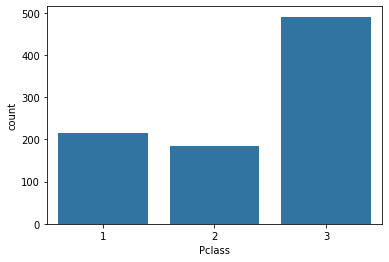

In [8]:
import seaborn as sns
print(df['Pclass'].value_counts())
#sns.countplot(x='Survived', data=df)
sns.countplot(x='Pclass', data=df)

### b. Pies chart

<Axes: >

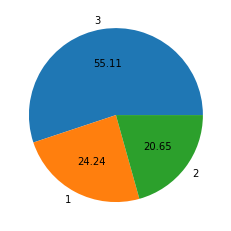

In [28]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%.2f')

All options for basic ploting
| Plot Type | Best For                   |
| --------- | -------------------------- |
| bar       | Category comparison        |
| barh      | Same as bar but horizontal |
| line      | Trends                     |
| hist      | Distribution               |
| box       | Outliers & spread          |
| kde       | Smooth distribution        |
| scatter   | Relationship               |
| area      | Cumulative data            |
| hexbin    | Large dataset density      |


### 2. Numerical Data

#### a. Histogram
It is helping us to undertsand the distribution of a column

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

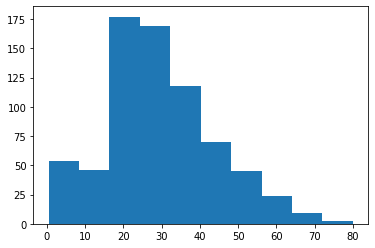

In [30]:
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=10)

<Axes: ylabel='Density'>

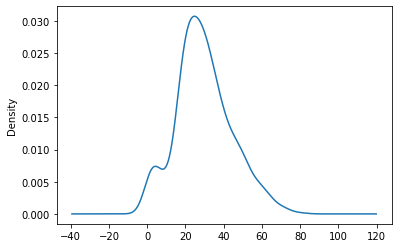

In [32]:
df['Age'].plot(kind='kde')

It has skew value positive means it is lightly right skewed
It means mean > median > mode.

*   List item
*   List item


for left skew  mean < median < mode.
for perfect data mean=median=mode

#### c. Boxplot

512.3292


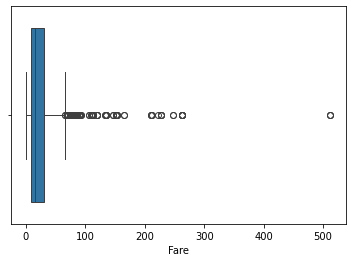

In [34]:
sns.boxplot(x=df['Fare'])
print(df['Fare'].max())

Here so many otliers which are more than 100 , as they are outside the box

## Multivariate analysis
### 1. Scatter plot
It will define relationship between 2 columns
##### a. Numerical numerical

     total_bill   tip     sex smoker   day    time  size
124       12.48  2.52  Female     No  Thur   Lunch     2
75        10.51  1.25    Male     No   Sat  Dinner     2
36        16.31  2.00    Male     No   Sat  Dinner     3
234       15.53  3.00    Male    Yes   Sat  Dinner     2
208       24.27  2.03    Male    Yes   Sat  Dinner     2


<Axes: xlabel='total_bill', ylabel='tip'>

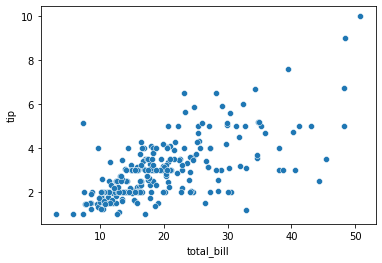

In [13]:
tips = sns.load_dataset('tips')
print(tips.sample(5))
sns.scatterplot(x='total_bill',y='tip',data=tips)

<Axes: xlabel='total_bill', ylabel='tip'>

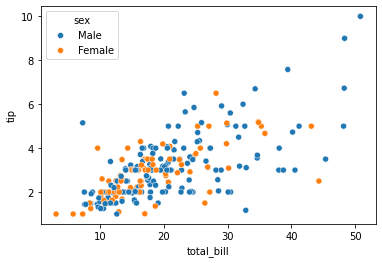

In [14]:
sns.scatterplot(x='total_bill',y='tip',data=tips, hue ='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

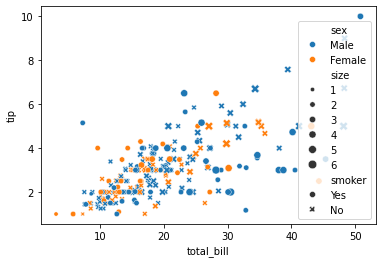

In [15]:
sns.scatterplot(x='total_bill',y='tip',data=tips, hue='sex',style='smoker', size= 'size')

#### 2. Bar plot

<Axes: xlabel='Pclass', ylabel='Fare'>

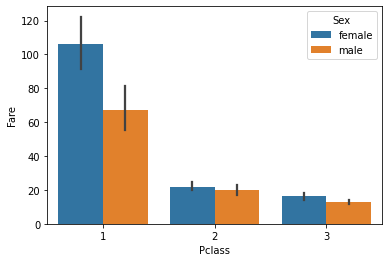

In [16]:
sns.barplot(x='Pclass',y='Fare',hue='Sex',data=df)

It says depending of Pclass rank fare is high means 1st class pasengers gave more fare
Similarly Femare fares are little less than male fares

### 3. Box plot (Categorical numerical)

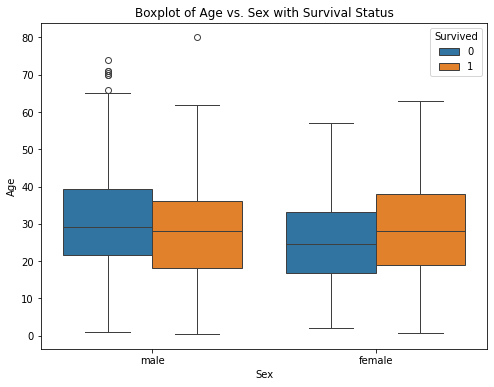

In [36]:
# prompt: boxplot using sns on sex age and survived


# Assuming 'df' is your DataFrame and it's already loaded
# If not, uncomment the next line and replace 'Titanic-Dataset.csv' with your file path
# df = pd.read_csv('Titanic-Dataset.csv')

# Create the boxplot
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
sns.boxplot(x='Sex', y='Age', hue='Survived', data=df)
plt.title('Boxplot of Age vs. Sex with Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.show()


Here age is numerical but survived other columns are categorical

### 4. Distplot (categorical numerical)

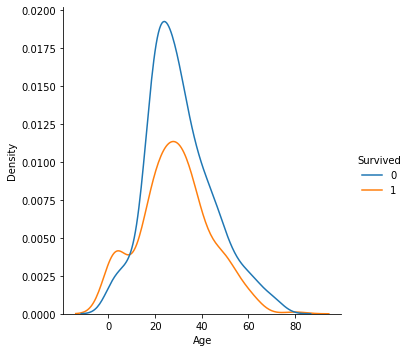

In [37]:
sns.displot(x='Age', hue='Survived', data=df, kind='kde')



*   When age is around 20 to 40 population is high
*   For younger people probability of survive is more than not survive
*   similarly older people  probability of not survive is more than  survive



### 5. Heatmap categorical categorical

<Axes: xlabel='Survived', ylabel='Pclass'>

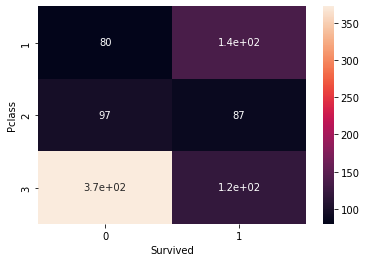

In [38]:
# Create the crosstab
crosstab = pd.crosstab(df['Pclass'], df['Survived'])

# Create the heatmap
sns.heatmap(crosstab, annot=True)


### 6. Pair plot (categorical - Numerical)

     sepal_length  sepal_width  petal_length  petal_width     species
48            5.3          3.7           1.5          0.2      setosa
72            6.3          2.5           4.9          1.5  versicolor
40            5.0          3.5           1.3          0.3      setosa
142           5.8          2.7           5.1          1.9   virginica
52            6.9          3.1           4.9          1.5  versicolor


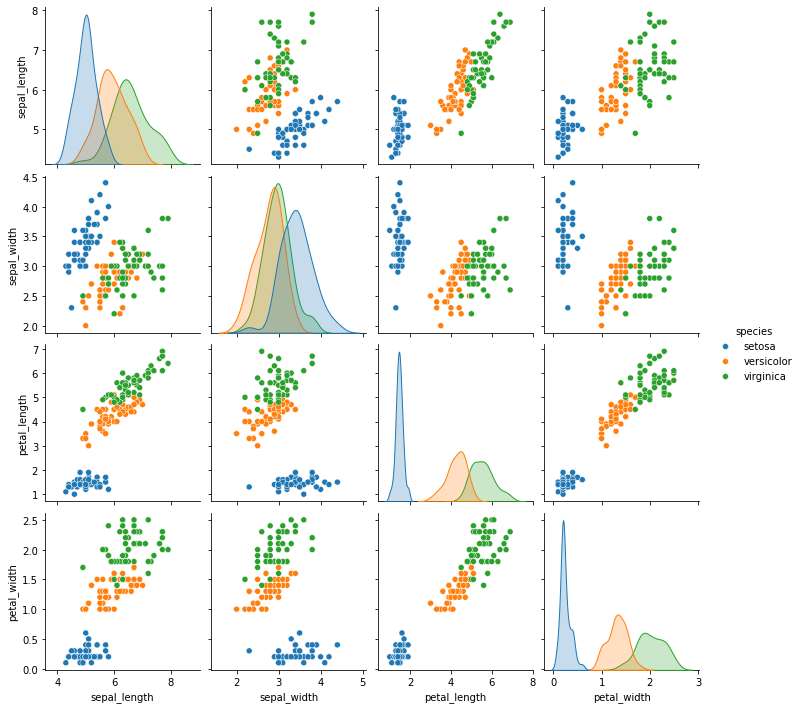

In [20]:
iris = sns.load_dataset('iris')
print(iris.sample(5))
sns.pairplot(iris, hue='species')


### &. Line plot (numerical -numerical)
Its a special case of scatter plot which is time based

In [39]:
flights = sns.load_dataset('flights')
print(flights.sample(5))


     year month  passengers
107  1957   Dec         336
37   1952   Feb         180
112  1958   May         363
100  1957   May         355
65   1954   Jun         264


    year  passengers
3   1952        2364
11  1960        5714
8   1957        4421
10  1959        5140
6   1955        3408


<Axes: xlabel='year', ylabel='passengers'>

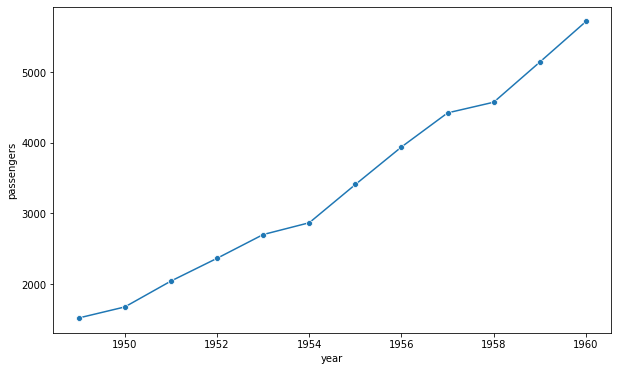

In [40]:
# prompt: group by year

import pandas as pd
# Assuming 'df' is your DataFrame and it has a 'Year' column
# If not, replace 'Year' with the actual column name representing the year

# Convert the 'Year' column to datetime if it's not already
# This is crucial for proper grouping
# df['Year'] = pd.to_datetime(df['Year']).dt.year


grouped_flights = flights.groupby('year')['passengers'].sum().reset_index()
print(grouped_flights.sample(5))
# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='passengers', data=grouped_flights, marker='o')



## Pandas profiling
!pip install ydata-profiling

In [41]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile.to_file("Titanic.html")


ModuleNotFoundError: No module named 'ydata_profiling'